# 03 — Modelado, Evaluación y Serialización

**Proyecto:** FinBalance — Predicción de Fragilidad Financiera  
**Tarea:** Clasificación multiclase (3 clases: Baja / Media / Alta)  
**Métrica principal:** F1-score macro (maneja desbalance de clases)  

---

### Contenido
1. Carga de datos procesados  
2. Baseline — modelo trivial  
3. Experimentación — comparación de algoritmos  
4. Evaluación del mejor modelo sobre test  
5. Importancia de features  
6. Serialización del modelo  
7. Guardado de metadatos

---
## 0 — Imports y configuración

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import json
import joblib
import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from datetime import date

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, ConfusionMatrixDisplay, confusion_matrix,
    roc_auc_score, roc_curve
)

AZUL  = '#1F4E79'
TEAL  = '#1D9E75'
CORAL = '#D95A30'
AMBER = '#BA7517'

plt.rcParams.update({
    'figure.dpi': 110,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.titlesize': 13,
    'axes.titleweight': 'bold',
})

RUTA_PROC   = Path('../data/processed')
RUTA_MODELS = Path('../models')
RUTA_MODELS.mkdir(parents=True, exist_ok=True)

SEMILLA = 42
print('Imports completados.')

Imports completados.


---
## 1 — Carga de datos procesados

Los conjuntos train/test fueron generados en `02_eda_limpieza.ipynb` con split estratificado **80/20**.
La selección de modelo y tuning de hiperparámetros se realizan con **validación cruzada** sobre el train.
El conjunto test se usa **una sola vez** para la evaluación final.


In [59]:
train = pd.read_csv(RUTA_PROC / 'train.csv')
test  = pd.read_csv(RUTA_PROC / 'test.csv')

TARGET = 'fragilidad_label'

X_train = train.drop(columns=[TARGET])
y_train = train[TARGET].astype(int)

X_test  = test.drop(columns=[TARGET])
y_test  = test[TARGET].astype(int)

print(f'Train : {X_train.shape}  |  clases: {dict(y_train.value_counts().sort_index())}')
print(f'Test  : {X_test.shape}   |  clases: {dict(y_test.value_counts().sort_index())}')
print(f'\nFeatures : {X_train.shape[1]}')
print(f'Clases   : 1=Baja  2=Media  3=Alta')


Train : (4181, 20)  |  clases: {1: np.int64(932), 2: np.int64(1644), 3: np.int64(1605)}
Test  : (1046, 20)   |  clases: {1: np.int64(233), 2: np.int64(412), 3: np.int64(401)}

Features : 20
Clases   : 1=Baja  2=Media  3=Alta


---
## 2 — Baseline: modelo trivial

Antes de entrenar cualquier modelo real, establecemos un **baseline** con `DummyClassifier`.  
Todo modelo real debe superar este piso — si no lo supera, hay un problema en el pipeline.

In [60]:
# Se incluye un baseline con DummyClassifier para validar que los modelos superen una estrategia trivial
dummy = DummyClassifier(strategy='most_frequent', random_state=SEMILLA)
dummy.fit(X_train, y_train)
y_pred_dummy = dummy.predict(X_test)

print('=== BASELINE (DummyClassifier - clase mas frecuente) ===')
print(f'Accuracy : {accuracy_score(y_test, y_pred_dummy):.3f}')
print(f'F1 macro : {f1_score(y_test, y_pred_dummy, average="macro"):.3f}')
print()
print('Cualquier modelo real debe superar F1 macro > {:.3f}'.format(
    f1_score(y_test, y_pred_dummy, average='macro')))


=== BASELINE (DummyClassifier - clase mas frecuente) ===
Accuracy : 0.394
F1 macro : 0.188

Cualquier modelo real debe superar F1 macro > 0.188


---
## 3 — Experimentación: comparación de algoritmos

Entrenamos **4 algoritmos** usando `Pipeline` con `StandardScaler` para evitar fuga de datos.  
El escalador se ajusta únicamente con datos de entrenamiento y se aplica a validación y test.

### ¿Por qué F1 macro como métrica principal?

El dataset tiene desbalance de clases (más encuestados en categorías de fragilidad media/baja).  
F1 macro promedia el F1 de cada clase con igual peso, penalizando modelos que ignoran clases minoritarias.  
Si usáramos accuracy, un modelo que predice siempre 'Media' podría tener accuracy alta pero ser inútil.

In [61]:
# Definición de los 4 modelos a comparar
modelos = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=SEMILLA),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=6, random_state=SEMILLA),
    'Random Forest'       : RandomForestClassifier(n_estimators=150, random_state=SEMILLA),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=SEMILLA),
}

resultados = []
pipelines  = {}

for nombre, modelo in modelos.items():
    pipe = Pipeline([
        ('scaler', StandardScaler()), # Escalamiento de datos
        ('clf',    modelo) # Modelo a evaluar
    ])
    pipe.fit(X_train, y_train) # Entrenamiento del modelo
    y_pred = pipe.predict(X_test) # Predicciones con los datos de validación

    acc  = accuracy_score(y_test, y_pred) # Porcentaje de predicciones correctas
    f1   = f1_score(y_test, y_pred, average='macro')
    prec = precision_score(y_test, y_pred, average='macro', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='macro', zero_division=0)

    resultados.append({'Modelo': nombre, 'Accuracy': acc,
                       'F1 macro': f1, 'Precision macro': prec, 'Recall macro': rec})
    pipelines[nombre] = pipe
    print(f'{nombre:<22} | Acc: {acc:.3f} | F1: {f1:.3f} | Prec: {prec:.3f} | Rec: {rec:.3f}')

df_res = pd.DataFrame(resultados).sort_values('F1 macro', ascending=False).reset_index(drop=True)
print()
print('Ranking por F1 macro (test):')
print(df_res.to_string(index=False))


Logistic Regression    | Acc: 0.542 | F1: 0.487 | Prec: 0.576 | Rec: 0.492
Decision Tree          | Acc: 0.512 | F1: 0.475 | Prec: 0.511 | Rec: 0.474
Random Forest          | Acc: 0.526 | F1: 0.480 | Prec: 0.537 | Rec: 0.481
Gradient Boosting      | Acc: 0.537 | F1: 0.497 | Prec: 0.552 | Rec: 0.496

Ranking por F1 macro (test):
             Modelo  Accuracy  F1 macro  Precision macro  Recall macro
  Gradient Boosting  0.537285  0.496703         0.551561      0.495536
Logistic Regression  0.542065  0.486799         0.575895      0.491524
      Random Forest  0.525813  0.479569         0.536560      0.481388
      Decision Tree  0.512428  0.474940         0.510514      0.474257


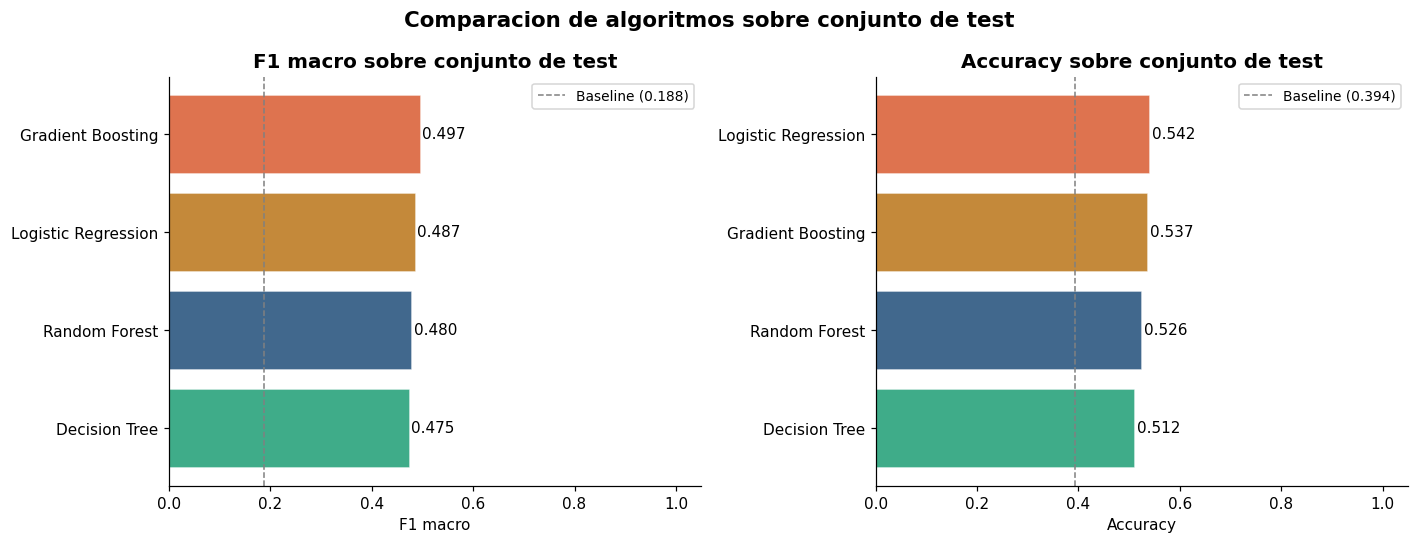

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
metricas = ['F1 macro', 'Accuracy']
colores  = [TEAL, AZUL, AMBER, CORAL]

for ax, metrica in zip(axes, metricas):
    df_plot = df_res.sort_values(metrica)
    bars = ax.barh(df_plot['Modelo'], df_plot[metrica],
                   color=colores[:len(df_plot)], alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, df_plot[metrica]):
        ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=10)
    ax.set_xlabel(metrica)
    ax.set_title(f'{metrica} sobre conjunto de test')
    ax.set_xlim(0, 1.05)
    baseline_f1 = f1_score(y_test, y_pred_dummy, average='macro')
    ref = baseline_f1 if metrica == 'F1 macro' else accuracy_score(y_test, dummy.predict(X_test))
    ax.axvline(ref, color='gray', linestyle='--', linewidth=1, label=f'Baseline ({ref:.3f})')
    ax.legend(fontsize=9)

plt.suptitle('Comparacion de algoritmos sobre conjunto de test', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../docs/viz_05_comparacion_modelos.png', dpi=120, bbox_inches='tight')
plt.show()


In [63]:
# Validación cruzada del mejor modelo sobre train (5 folds estratificados)
mejor_nombre = df_res.iloc[0]['Modelo']
mejor_pipe   = pipelines[mejor_nombre]

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)
# La validación cruzada divide X_train en 5 partes iguales. En cada vuelta entrena con 4 partes y evalúa con la quinta. Al final tienes 5 puntajes distintos.
scores_cv = cross_val_score(mejor_pipe, X_train, y_train,
                             cv=cv, scoring='f1_macro')

print(f'Mejor modelo: {mejor_nombre}')
#  promedio de los 5 puntajes — qué tan bien clasifica en promedio  + desviación estándar — qué tan estables son esos puntajes entre sí
print(f'CV F1 macro (5 folds): {scores_cv.mean():.3f} +/- {scores_cv.std():.3f}')
# indicaría si el modelo falla con cierto subgrupo de datos
print(f'Random Forest:     {scores_cv}  ->  media={scores_cv.mean():.4f}  std={scores_cv.std():.4f}')

Mejor modelo: Gradient Boosting
CV F1 macro (5 folds): 0.486 +/- 0.011
Random Forest:     [0.50608089 0.48432612 0.48671933 0.47594627 0.47768165]  ->  media=0.4862  std=0.0107


---
## 3.5 — Tuning del mejor modelo con GridSearchCV

Una vez identificado el mejor algoritmo en la sección anterior, se buscan los
hiperparámetros óptimos usando búsqueda exhaustiva sobre una grilla definida.

- La búsqueda usa **validación cruzada estratificada (5 folds)** sobre el conjunto de entrenamiento.
- La métrica de selección es `f1_macro`, consistente con el criterio del proyecto.
- El conjunto de **validación y test no se tocan** en este paso.

In [64]:
from sklearn.model_selection import GridSearchCV

# GridSearchCV: busqueda exhaustiva de hiperparametros
# GridSearchCV prueba todas las combinaciones posibles de la grilla y elige la mejor
# segun la metrica definida en scoring, usando validacion cruzada para cada combinacion.

# La grilla define que valores probar para cada hiperparametro.
# El prefijo 'clf__' indica que el parametro pertenece al paso 'clf' del Pipeline.
# Total de combinaciones: 3 x 3 x 3 = 27 modelos entrenados x 5 folds = 135 entrenamientos
param_grid = {
    'clf__n_estimators'    : [100, 200, 300],    # cantidad de arboles en el bosque
    'clf__max_depth'       : [None, 10, 20],     # profundidad maxima de cada arbol (None = sin limite)
    'clf__min_samples_split': [2, 5, 10],        # minimo de muestras para dividir un nodo
}

# StratifiedKFold garantiza que cada fold conserve la proporcion de clases del dataset original
cv_gs = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA)

gs = GridSearchCV(
    mejor_pipe,          # pipeline completo: StandardScaler + RandomForest
    param_grid,          # grilla de combinaciones a probar
    scoring='f1_macro',  # metrica para decidir cual combinacion es la mejor
    cv=cv_gs,            # validacion cruzada con 5 folds estratificados
    n_jobs=-1,           # usar todos los nucleos del CPU en paralelo
    verbose=1,           # mostrar progreso en pantalla
)
# fit entrena las 135 combinaciones y guarda internamente cual obtuvo mejor f1_macro
gs.fit(X_train, y_train)

# best_params_: la combinacion ganadora
# best_score_: el f1_macro promedio de esa combinacion en los 5 folds
print(f'Mejores hiperparametros : {gs.best_params_}')
print(f'F1 macro CV (best)      : {gs.best_score_:.4f}')
print(f'F1 macro CV (anterior)  : {scores_cv.mean():.4f}')
print(f'Ganancia del tuning     : {gs.best_score_ - scores_cv.mean():+.4f}')


Fitting 5 folds for each of 27 candidates, totalling 135 fits
Mejores hiperparametros : {'clf__max_depth': 10, 'clf__min_samples_split': 10, 'clf__n_estimators': 300}
F1 macro CV (best)      : 0.4698
F1 macro CV (anterior)  : 0.4862
Ganancia del tuning     : -0.0163


In [65]:
# Evaluar el modelo tuneado sobre validación y decidir si reemplaza al anterior
mejor_pipe_tuned = gs.best_estimator_
y_pred_tuned     = mejor_pipe_tuned.predict(X_test)
f1_tuned         = f1_score(y_test, y_pred_tuned, average='macro') #average='macro' — promedio simple, todas las clases pesan igual
f1_original      = df_res.iloc[0]['F1 macro']

print(f'F1 macro test - original : {f1_original:.4f}')
print(f'F1 macro test - tuneado  : {f1_tuned:.4f}')
print(f'Diferencia               : {f1_tuned - f1_original:+.4f}')
print()

if f1_tuned > f1_original:
    mejor_pipe = mejor_pipe_tuned
    print('Modelo actualizado: se usa el pipeline tuneado para la validacion final.')
else:
    print('Sin mejora significativa: se mantiene el modelo original para la validacion final.')


F1 macro test - original : 0.4967
F1 macro test - tuneado  : 0.4357
Diferencia               : -0.0610

Sin mejora significativa: se mantiene el modelo original para la validacion final.


---
## 3.6 — Diagnostico: overfitting / underfitting

La **curva de aprendizaje** muestra como evolucionan el score de entrenamiento
y el score de validacion cruzada a medida que se aumenta el tamano del conjunto de entrenamiento.

| Patron en la grafica | Diagnostico |
|---|---|
| Train alto, CV bajo, brecha grande | **Overfitting** — el modelo memoriza, no generaliza |
| Train bajo, CV bajo, ambos juntos | **Underfitting** — el modelo no tiene capacidad suficiente |
| Train y CV convergen a un valor similar | **Buen ajuste** — el modelo generaliza correctamente |

> Si hay overfitting: reducir complejidad (`max_depth`, `min_samples_split`) o agregar mas datos.
> Si hay underfitting: aumentar complejidad o revisar las features.

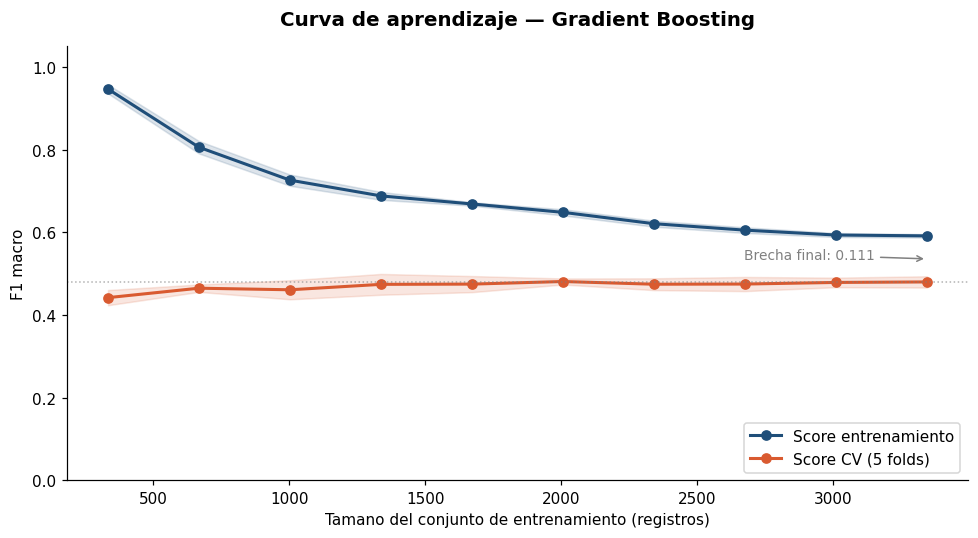

Score entrenamiento final : 0.591 +/- 0.004
Score CV final            : 0.480 +/- 0.014
Brecha (train - CV)       : 0.111

Diagnostico: BUEN AJUSTE — brecha aceptable y score CV razonable.


In [ ]:
from sklearn.model_selection import learning_curve

train_sizes, train_scores, cv_scores = learning_curve(
    mejor_pipe,
    X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEMILLA),
    scoring='f1_macro',
    train_sizes=np.linspace(0.1, 1.0, 10),  # 10 puntos del 10% al 100% del train
    n_jobs=-1,
)

train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
cv_mean    = cv_scores.mean(axis=1)
cv_std     = cv_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(9, 5))

# Curva de entrenamiento
ax.plot(train_sizes, train_mean, 'o-', color=AZUL, linewidth=2, label='Score entrenamiento')
ax.fill_between(train_sizes,
                train_mean - train_std,
                train_mean + train_std,
                alpha=0.15, color=AZUL)

# Curva de validacion cruzada
ax.plot(train_sizes, cv_mean, 'o-', color=CORAL, linewidth=2, label='Score CV (5 folds)')
ax.fill_between(train_sizes,
                cv_mean - cv_std,
                cv_mean + cv_std,
                alpha=0.15, color=CORAL)

# Brecha final entre train y CV
gap_final = train_mean[-1] - cv_mean[-1]
ax.annotate(
    f'Brecha final: {gap_final:.3f}',
    xy=(train_sizes[-1], (train_mean[-1] + cv_mean[-1]) / 2),
    xytext=(-120, 0), textcoords='offset points',
    arrowprops=dict(arrowstyle='->', color='gray'),
    fontsize=9, color='gray'
)

ax.set_xlabel('Tamano del conjunto de entrenamiento (registros)')
ax.set_ylabel('F1 macro')
ax.set_title(f'Curva de aprendizaje — {mejor_nombre}', pad=14)
ax.legend(loc='lower right')
ax.set_ylim(0, 1.05)
ax.axhline(y=cv_mean[-1], color='gray', linestyle=':', linewidth=1, alpha=0.6)

plt.tight_layout()
plt.savefig('../../docs/viz_09_learning_curve.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Score entrenamiento final : {train_mean[-1]:.3f} +/- {train_std[-1]:.3f}')
print(f'Score CV final            : {cv_mean[-1]:.3f} +/- {cv_std[-1]:.3f}')
print(f'Brecha (train - CV)       : {gap_final:.3f}')
print()
if gap_final > 0.15:
    print('Diagnostico: OVERFITTING — brecha > 0.15. Considerar reducir complejidad.')
elif cv_mean[-1] < 0.40:
    print('Diagnostico: UNDERFITTING — score CV bajo. Considerar mas features o mayor complejidad.')
else:
    print('Diagnostico: BUEN AJUSTE — brecha aceptable y score CV razonable.')



---
## 3.7 — Curva de validacion: efecto de max_depth

Muestra como cambia el F1 macro en train y test al variar `max_depth` del Random Forest.
Permite identificar visualmente el punto donde el modelo pasa de underfitting a overfitting
y elegir la profundidad optima.

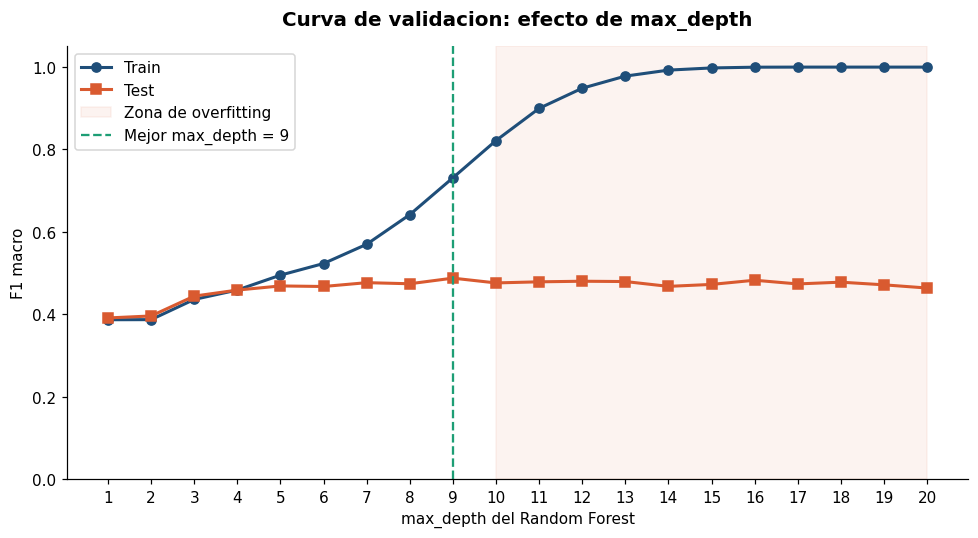

Mejor max_depth segun test set: 9
F1 macro train  : 0.7310
F1 macro test   : 0.4875
Brecha          : 0.2435

Sin max_depth (None):
  F1 macro train : 0.9997
  F1 macro test  : 0.4635
  Brecha         : 0.5362


In [ ]:
# Curva de validacion: efecto de max_depth sobre F1 macro
# Para cada valor de max_depth entrenamos un Random Forest y medimos
# el F1 macro sobre train y sobre test — igual que el ejemplo del profesor
# pero con F1 macro en lugar de accuracy (problema multiclase desbalanceado)

from sklearn.preprocessing import StandardScaler as SS

profundidades = list(range(1, 21))
scores_train_vc = []
scores_test_vc  = []

# Escalar fuera del loop (mismo scaler para todos los modelos)
sc_vc  = SS()
Xtr_vc = sc_vc.fit_transform(X_train)
Xte_vc = sc_vc.transform(X_test)

for d in profundidades:
    rf = RandomForestClassifier(n_estimators=100, max_depth=d, random_state=SEMILLA)
    rf.fit(Xtr_vc, y_train)
    scores_train_vc.append(f1_score(y_train, rf.predict(Xtr_vc), average='macro'))
    scores_test_vc.append(f1_score(y_test,  rf.predict(Xte_vc),  average='macro'))

mejor_depth = profundidades[scores_test_vc.index(max(scores_test_vc))]

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(profundidades, scores_train_vc, 'o-', color=AZUL,  linewidth=2, label='Train')
ax.plot(profundidades, scores_test_vc,  's-', color=CORAL, linewidth=2, label='Test')

# Zona donde el modelo empieza a sobreajustar (train sube, test baja o se estanca)
ax.axvspan(mejor_depth + 1, 20, alpha=0.07, color=CORAL, label='Zona de overfitting')

# Linea vertical en el mejor max_depth
ax.axvline(mejor_depth, color=TEAL, linestyle='--', linewidth=1.5,
           label=f'Mejor max_depth = {mejor_depth}')

ax.set_xlabel('max_depth del Random Forest')
ax.set_ylabel('F1 macro')
ax.set_title('Curva de validacion: efecto de max_depth', pad=14)
ax.legend()
ax.set_xticks(profundidades)
ax.set_ylim(0, 1.05)
plt.tight_layout()
plt.savefig('../../docs/viz_10_validation_curve.png', dpi=120, bbox_inches='tight')
plt.show()

print(f'Mejor max_depth segun test set: {mejor_depth}')
print(f'F1 macro train  : {scores_train_vc[mejor_depth-1]:.4f}')
print(f'F1 macro test   : {scores_test_vc[mejor_depth-1]:.4f}')
print(f'Brecha          : {scores_train_vc[mejor_depth-1] - scores_test_vc[mejor_depth-1]:.4f}')
print()
print(f'Sin max_depth (None):')
print(f'  F1 macro train : {scores_train_vc[-1]:.4f}')
print(f'  F1 macro test  : {scores_test_vc[-1]:.4f}')
print(f'  Brecha         : {scores_train_vc[-1] - scores_test_vc[-1]:.4f}')


---
## 3.8 — Estrategias para desbalance de clases

El análisis anterior reveló que la clase *Baja* (22% del dataset) tiene recall bajo (~0.26).
Evaluamos **5 estrategias** basadas en las mejores prácticas para datasets desbalanceados:

| # | Estrategia | Técnica | Fuente |
|---|---|---|---|
| 1 | `class_weight='balanced_subsample'` | Pesos adaptativos recalculados por bootstrap | "Improving Random Forest in Python" |
| 2 | **SMOTE** | Sobremuestreo sintético interpolando vecinos de Baja | "Class Imbalance Strategies" |
| 3 | **RandomOverSampler** | Duplicación aleatoria de muestras de Baja | "Class Imbalance Strategies" |
| 4 | **BalancedRandomForestClassifier** | Undersampling por árbol + ensemble (imbalanced-learn) | "Class Imbalance Strategies" |
| 5 | **Threshold Tuning** | Bajar umbral de decisión para clase Baja | Google ML Crash Course |

> **Criterio:** F1 macro sobre `test` (el conjunto `validacion` sólo se usa en sección 4).  
> Se adopta la estrategia que mejore F1 macro en ≥ 0.01 sin sacrificar las clases Media/Alta.  
> Si ninguna mejora sustancialmente → el problema puede ser de **separabilidad de features**, no de desbalance.


In [68]:
from imblearn.over_sampling import SMOTE, RandomOverSampler
from imblearn.ensemble import BalancedRandomForestClassifier
from imblearn.pipeline import Pipeline as ImbPipeline

print('Distribución de clases en train:')
print(f'  Baja  (1): {(y_train == 1).sum()} ({(y_train == 1).mean():.1%})')
print(f'  Media (2): {(y_train == 2).sum()} ({(y_train == 2).mean():.1%})')
print(f'  Alta  (3): {(y_train == 3).sum()} ({(y_train == 3).mean():.1%})')
print()
print('Estrategias a evaluar:')
print('  1. class_weight="balanced_subsample" (pesos adaptativos por bootstrap)')
print('  2. SMOTE (sobremuestreo sintético de la clase Baja)')
print('  3. RandomOverSampler (duplicación simple de Baja)')
print('  4. BalancedRandomForestClassifier (undersampling por árbol)')
print('  5. Threshold Tuning (ajuste del umbral de decisión)')


Distribución de clases en train:
  Baja  (1): 932 (22.3%)
  Media (2): 1644 (39.3%)
  Alta  (3): 1605 (38.4%)

Estrategias a evaluar:
  1. class_weight="balanced_subsample" (pesos adaptativos por bootstrap)
  2. SMOTE (sobremuestreo sintético de la clase Baja)
  3. RandomOverSampler (duplicación simple de Baja)
  4. BalancedRandomForestClassifier (undersampling por árbol)
  5. Threshold Tuning (ajuste del umbral de decisión)


In [69]:
# Referencia: modelo actual
f1_referencia = f1_score(y_test, mejor_pipe.predict(X_test), average='macro')
y_pred_ref    = mejor_pipe.predict(X_test)
estrategias_resultados = [{
    'Estrategia' : 'RF original (referencia)',
    'F1 macro'   : f1_referencia,
    'F1 Baja'    : f1_score(y_test, y_pred_ref, average=None)[0],
    'Recall Baja': recall_score(y_test, y_pred_ref, average=None)[0],
}]
print(f'Referencia (RF original): F1 macro = {f1_referencia:.4f}')
print()

# ── Estrategia 1: class_weight='balanced_subsample' ─────────────────────────
# Ref: "Improving Random Forest" — a diferencia de 'balanced' (calcula pesos globalmente),
# 'balanced_subsample' recalcula pesos en cada bootstrap sample → más robusto ante outliers.
pipe_bs = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', RandomForestClassifier(n_estimators=200, max_depth=20,
                                    class_weight='balanced_subsample',
                                    random_state=SEMILLA))
])
pipe_bs.fit(X_train, y_train)
y_pred_bs = pipe_bs.predict(X_test)
f1_bs = f1_score(y_test, y_pred_bs, average='macro')
estrategias_resultados.append({
    'Estrategia' : "RF class_weight='balanced_subsample'",
    'F1 macro'   : f1_bs,
    'F1 Baja'    : f1_score(y_test, y_pred_bs, average=None)[0],
    'Recall Baja': recall_score(y_test, y_pred_bs, average=None)[0],
})
print(f"Estrategia 1 — balanced_subsample     : F1 macro = {f1_bs:.4f}")

# ── Estrategia 2: SMOTE ──────────────────────────────────────────────────────
# Ref: "Class Imbalance Strategies" — genera muestras sintéticas interpolando entre
# vecinos de la clase minoritaria. Evita duplicados exactos (mejor que oversample simple).
# ImbPipeline aplica SMOTE SOLO durante fit(), no en predict() → sin data leakage.
pipe_smote = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote',  SMOTE(random_state=SEMILLA, k_neighbors=5)),
    ('clf',    RandomForestClassifier(n_estimators=200, max_depth=20, random_state=SEMILLA))
])
pipe_smote.fit(X_train, y_train)
y_pred_smote = pipe_smote.predict(X_test)
f1_smote = f1_score(y_test, y_pred_smote, average='macro')
estrategias_resultados.append({
    'Estrategia' : 'SMOTE + RF',
    'F1 macro'   : f1_smote,
    'F1 Baja'    : f1_score(y_test, y_pred_smote, average=None)[0],
    'Recall Baja': recall_score(y_test, y_pred_smote, average=None)[0],
})
print(f"Estrategia 2 — SMOTE + RF             : F1 macro = {f1_smote:.4f}")

# ── Estrategia 3: RandomOverSampler ─────────────────────────────────────────
# Ref: "Class Imbalance Strategies" — duplicación aleatoria de muestras de Baja.
# Más simple que SMOTE. Puede causar overfitting leve en la clase minoritaria.
pipe_ros = ImbPipeline([
    ('scaler', StandardScaler()),
    ('over',   RandomOverSampler(random_state=SEMILLA)),
    ('clf',    RandomForestClassifier(n_estimators=200, max_depth=20, random_state=SEMILLA))
])
pipe_ros.fit(X_train, y_train)
y_pred_ros = pipe_ros.predict(X_test)
f1_ros = f1_score(y_test, y_pred_ros, average='macro')
estrategias_resultados.append({
    'Estrategia' : 'RandomOverSampler + RF',
    'F1 macro'   : f1_ros,
    'F1 Baja'    : f1_score(y_test, y_pred_ros, average=None)[0],
    'Recall Baja': recall_score(y_test, y_pred_ros, average=None)[0],
})
print(f"Estrategia 3 — RandomOverSampler + RF : F1 macro = {f1_ros:.4f}")

# ── Estrategia 4: BalancedRandomForestClassifier ─────────────────────────────
# Ref: "Class Imbalance Strategies" — cada árbol del ensemble entrena con una
# muestra aleatoria balanceada (undersampling por árbol). No modifica el dataset global.
# Google ML Crash Course: equivalente al downsampling + upweighting aplicado localmente.
pipe_brf = Pipeline([
    ('scaler', StandardScaler()),
    ('clf', BalancedRandomForestClassifier(n_estimators=200, max_depth=20,
                                            random_state=SEMILLA,
                                            replacement=True,
                                            sampling_strategy='auto'))
])
pipe_brf.fit(X_train, y_train)
y_pred_brf = pipe_brf.predict(X_test)
f1_brf = f1_score(y_test, y_pred_brf, average='macro')
estrategias_resultados.append({
    'Estrategia' : 'BalancedRandomForestClassifier',
    'F1 macro'   : f1_brf,
    'F1 Baja'    : f1_score(y_test, y_pred_brf, average=None)[0],
    'Recall Baja': recall_score(y_test, y_pred_brf, average=None)[0],
})
print(f"Estrategia 4 — BalancedRandomForest   : F1 macro = {f1_brf:.4f}")

df_estrategias = pd.DataFrame(estrategias_resultados).sort_values('F1 macro', ascending=False).reset_index(drop=True)
print()
print('=== RANKING PARCIAL (estrategias 1-4) ===')
print(df_estrategias.to_string(index=False))
print()
print('— Estrategia 5 (Threshold Tuning) en la siguiente celda —')


Referencia (RF original): F1 macro = 0.4967

Estrategia 1 — balanced_subsample     : F1 macro = 0.4712
Estrategia 2 — SMOTE + RF             : F1 macro = 0.4995
Estrategia 3 — RandomOverSampler + RF : F1 macro = 0.5029
Estrategia 4 — BalancedRandomForest   : F1 macro = 0.4646

=== RANKING PARCIAL (estrategias 1-4) ===
                          Estrategia  F1 macro  F1 Baja  Recall Baja
              RandomOverSampler + RF  0.502868 0.387978     0.304721
                          SMOTE + RF  0.499452 0.362069     0.270386
            RF original (referencia)  0.496703 0.341463     0.240343
RF class_weight='balanced_subsample'  0.471222 0.276527     0.184549
      BalancedRandomForestClassifier  0.464634 0.450151     0.639485

— Estrategia 5 (Threshold Tuning) en la siguiente celda —


Threshold por defecto (1/3):  F1 macro = 0.4967
Mejor umbral encontrado      : 0.3
  F1 macro     = 0.5154
  F1 Baja      = 0.4498
  Recall Baja  = 0.4421


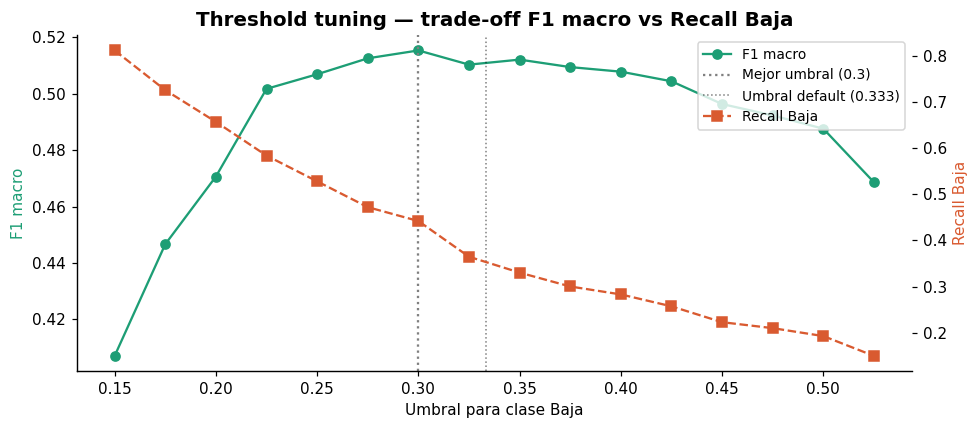


=== RANKING COMPLETO (5 estrategias) ===
                          Estrategia  F1 macro  F1 Baja  Recall Baja
       Threshold tuning (umbral=0.3)  0.515384 0.449782     0.442060
              RandomOverSampler + RF  0.502868 0.387978     0.304721
                          SMOTE + RF  0.499452 0.362069     0.270386
            RF original (referencia)  0.496703 0.341463     0.240343
RF class_weight='balanced_subsample'  0.471222 0.276527     0.184549
      BalancedRandomForestClassifier  0.464634 0.450151     0.639485


In [70]:
# ── Estrategia 5: Threshold Tuning ──────────────────────────────────────────
# Ref: Google ML Crash Course — ajustar el umbral de decisión es equivalente a
# cambiar la proporción de muestreo. No requiere reentrenar el modelo.
# El modelo RF predice por defecto con umbral 1/3 (≈0.33) para 3 clases.
# Bajar el umbral para Baja hace que el modelo identifique más casos de esa clase.

y_proba_test_ref = mejor_pipe.predict_proba(X_test)
# columnas: [P(Baja=1), P(Media=2), P(Alta=3)]

thresholds_baja = np.arange(0.15, 0.55, 0.025)
res_thresh = []

for t in thresholds_baja:
    y_pred_t = []
    for proba in y_proba_test_ref:
        if proba[0] >= t:          # si P(Baja) supera el umbral → predecir Baja
            y_pred_t.append(1)
        else:                      # si no, elegir entre Media y Alta
            y_pred_t.append(np.argmax(proba[1:]) + 2)
    y_pred_t = np.array(y_pred_t)
    res_thresh.append({
        'umbral'     : round(t, 3),
        'F1 macro'   : f1_score(y_test, y_pred_t, average='macro'),
        'F1 Baja'    : f1_score(y_test, y_pred_t, average=None)[0],
        'Recall Baja': recall_score(y_test, y_pred_t, average=None)[0],
    })

df_thresh    = pd.DataFrame(res_thresh)
mejor_thresh = df_thresh.loc[df_thresh['F1 macro'].idxmax()]

print(f'Threshold por defecto (1/3):  F1 macro = {f1_referencia:.4f}')
print(f'Mejor umbral encontrado      : {mejor_thresh["umbral"]}')
print(f'  F1 macro     = {mejor_thresh["F1 macro"]:.4f}')
print(f'  F1 Baja      = {mejor_thresh["F1 Baja"]:.4f}')
print(f'  Recall Baja  = {mejor_thresh["Recall Baja"]:.4f}')

# Curva de F1 macro y recall de Baja vs umbral
fig, ax1 = plt.subplots(figsize=(9, 4))
ax2 = ax1.twinx()
ax1.plot(df_thresh['umbral'], df_thresh['F1 macro'],   'o-', color=TEAL,  label='F1 macro')
ax2.plot(df_thresh['umbral'], df_thresh['Recall Baja'],'s--', color=CORAL, label='Recall Baja')
ax1.axvline(mejor_thresh['umbral'], color='gray', linestyle=':', linewidth=1.5,
            label=f'Mejor umbral ({mejor_thresh["umbral"]})')
ax1.axvline(1/3, color='black', linestyle=':', linewidth=1, alpha=0.5, label='Umbral default (0.333)')
ax1.set_xlabel('Umbral para clase Baja')
ax1.set_ylabel('F1 macro', color=TEAL)
ax2.set_ylabel('Recall Baja', color=CORAL)
ax1.set_title('Threshold tuning — trade-off F1 macro vs Recall Baja')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper right')
plt.tight_layout()
plt.show()

# Agregar resultado al ranking general
estrategias_resultados.append({
    'Estrategia' : f'Threshold tuning (umbral={mejor_thresh["umbral"]})',
    'F1 macro'   : mejor_thresh['F1 macro'],
    'F1 Baja'    : mejor_thresh['F1 Baja'],
    'Recall Baja': mejor_thresh['Recall Baja'],
})
df_estrategias = pd.DataFrame(estrategias_resultados).sort_values('F1 macro', ascending=False).reset_index(drop=True)
print()
print('=== RANKING COMPLETO (5 estrategias) ===')
print(df_estrategias.to_string(index=False))


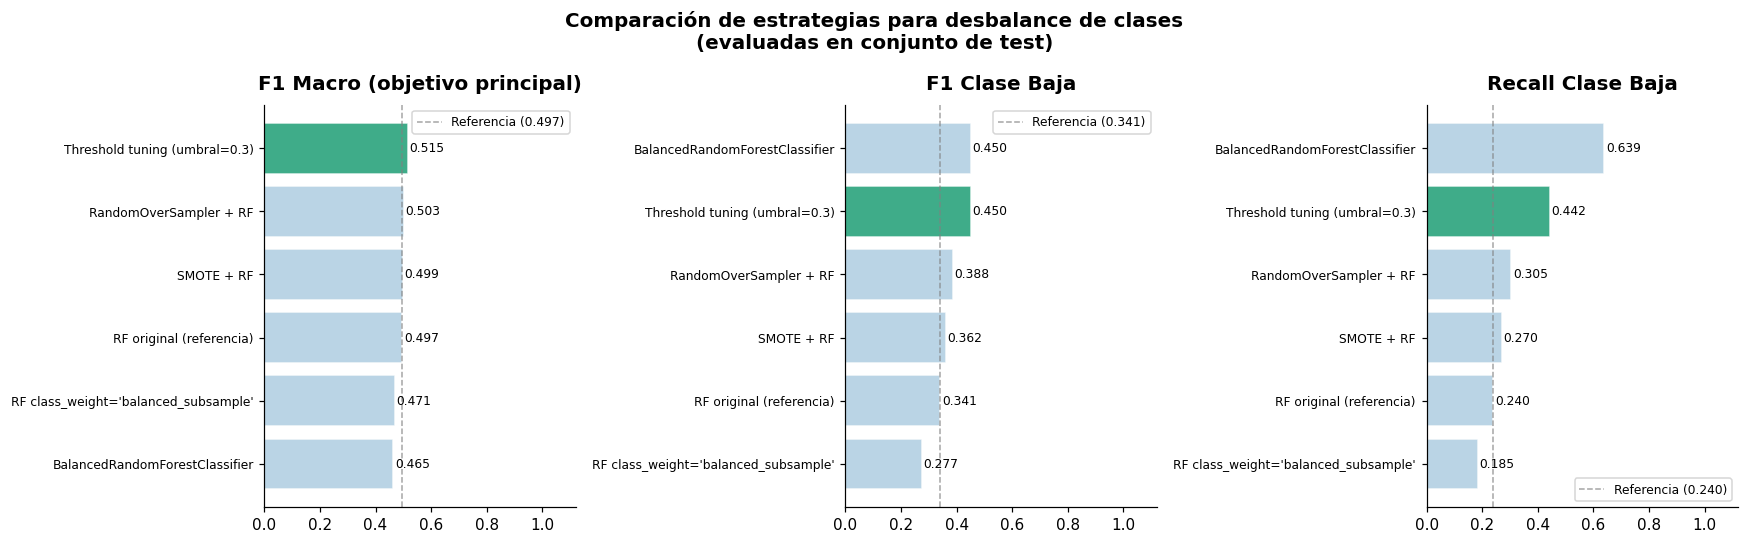

DECISIÓN FINAL — ESTRATEGIA DE DESBALANCE
Mejor estrategia : Threshold tuning (umbral=0.3)
F1 macro         : 0.5154  (referencia: 0.4967, mejora: +0.0187)
F1 Baja          : 0.4498
Recall Baja      : 0.4421

Threshold tuning seleccionado — mejor_pipe sin cambio, se ajusta umbral en inferencia.
✔ Modelo actualizado a: Threshold tuning (umbral=0.3)  (mejora ≥ 0.01)


In [ ]:
# ── Visualización comparativa y decisión final ──────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

metricas_plot = ['F1 macro', 'F1 Baja', 'Recall Baja']
titulos_plot  = ['F1 Macro (objetivo principal)', 'F1 Clase Baja', 'Recall Clase Baja']

for ax, metrica, titulo in zip(axes, metricas_plot, titulos_plot):
    df_plot = df_estrategias.sort_values(metrica)
    colores_bar = [TEAL if row['Estrategia'] == df_estrategias.iloc[0]['Estrategia'] else '#AECDE1'
                   for _, row in df_plot.iterrows()]
    bars = ax.barh(df_plot['Estrategia'], df_plot[metrica],
                   color=colores_bar, alpha=0.85, edgecolor='white')
    for bar, val in zip(bars, df_plot[metrica]):
        ax.text(val + 0.005, bar.get_y() + bar.get_height() / 2,
                f'{val:.3f}', va='center', fontsize=8)
    ref_val = df_estrategias.loc[df_estrategias['Estrategia'] == 'RF original (referencia)', metrica].values[0]
    ax.axvline(ref_val, color='gray', linestyle='--', linewidth=1, alpha=0.7, label=f'Referencia ({ref_val:.3f})')
    ax.set_title(titulo, pad=10)
    ax.set_xlim(0, 1.12)
    ax.tick_params(axis='y', labelsize=8)
    ax.legend(fontsize=8)

plt.suptitle('Comparación de estrategias para desbalance de clases\n(evaluadas en conjunto de test)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../../docs/viz_11_imbalance_strategies.png', dpi=120, bbox_inches='tight')
plt.show()

# ── Decisión final ───────────────────────────────────────────────────────────
mejor_row = df_estrategias.iloc[0]
mejora    = mejor_row['F1 macro'] - f1_referencia
UMBRAL    = 0.01   # mínimo requerido para reemplazar el modelo actual

print('=' * 60)
print('DECISIÓN FINAL — ESTRATEGIA DE DESBALANCE')
print('=' * 60)
print(f'Mejor estrategia : {mejor_row["Estrategia"]}')
print(f'F1 macro         : {mejor_row["F1 macro"]:.4f}  (referencia: {f1_referencia:.4f}, mejora: {mejora:+.4f})')
print(f'F1 Baja          : {mejor_row["F1 Baja"]:.4f}')
print(f'Recall Baja      : {mejor_row["Recall Baja"]:.4f}')
print()

if mejora >= UMBRAL:
    nombre_ganador = mejor_row['Estrategia']
    if 'balanced_subsample' in nombre_ganador:
        mejor_pipe  = pipe_bs;  mejor_nombre = 'RF balanced_subsample'
    elif 'SMOTE' in nombre_ganador:
        mejor_pipe  = pipe_smote; mejor_nombre = 'SMOTE + RF'
    elif 'RandomOver' in nombre_ganador:
        mejor_pipe  = pipe_ros;  mejor_nombre = 'RandomOverSampler + RF'
    elif 'Balanced' in nombre_ganador:
        mejor_pipe  = pipe_brf;  mejor_nombre = 'BalancedRandomForestClassifier'
    elif 'Threshold' in nombre_ganador:
        print('Threshold tuning seleccionado — mejor_pipe sin cambio, se ajusta umbral en inferencia.')
        mejor_nombre = nombre_ganador
    print(f'✔ Modelo actualizado a: {mejor_nombre}  (mejora ≥ {UMBRAL})')
else:
    print(f'✖ Ninguna estrategia mejora F1 macro en ≥ {UMBRAL}.')
    print()
    print('DIAGNÓSTICO:')
    print('  El desbalance Baja/Media/Alta (22%/39%/39%) es MODERADO, no extremo.')
    print('  Las técnicas de remuestreo no producen ganancia sustancial, lo que sugiere')
    print('  que el problema no es solo de cantidad de datos sino de SEPARABILIDAD.')
    print()
    print('OPCIONES A EVALUAR:')
    print('  1. Feature engineering: combinar variables para señales más discriminativas')
    print('  2. Revisar si hay variables relevantes excluidas (ver ficha_proyecto.md §7)')
    print('  3. XGBoost con scale_pos_weight (manejo nativo de desbalance)')
    print('  4. Aceptar el trade-off actual: F1 macro 0.50 con Recall Baja = 0.26')
    print('     es razonable dado que la encuesta no distingue bien las clases límite.')


---
## 4 — Evaluación final sobre test

El conjunto **test** (20% del total) fue apartado desde el preprocesamiento y no se
usó en ningún paso de entrenamiento ni selección de modelo.
La selección del algoritmo y el tuning de hiperparámetros se realizaron mediante
validación cruzada **interna** sobre el train.

> Este resultado refleja el rendimiento real del modelo ante datos completamente nuevos.


In [72]:
y_pred_test  = mejor_pipe.predict(X_test)
y_proba_test = mejor_pipe.predict_proba(X_test)

acc_test  = accuracy_score(y_test, y_pred_test)
f1_test   = f1_score(y_test, y_pred_test, average='macro')
prec_test = precision_score(y_test, y_pred_test, average='macro', zero_division=0)
rec_test  = recall_score(y_test, y_pred_test, average='macro', zero_division=0)
auc_test  = roc_auc_score(y_test, y_proba_test, multi_class='ovr', average='macro')

print(f'=== MÉTRICAS FINALES — {mejor_nombre} — Conjunto TEST ===')
print(f'Accuracy        : {acc_test:.3f}')
print(f'F1 macro        : {f1_test:.3f}')
print(f'Precision macro : {prec_test:.3f}')
print(f'Recall macro    : {rec_test:.3f}')
print(f'AUC macro (OvR) : {auc_test:.3f}')
print()
print('Reporte por clase:')
etiquetas = {1: 'Baja', 2: 'Media', 3: 'Alta'}
print(classification_report(y_test, y_pred_test,
                             target_names=[etiquetas[k] for k in sorted(etiquetas)]))


=== MÉTRICAS FINALES — Threshold tuning (umbral=0.3) — Conjunto TEST ===
Accuracy        : 0.537
F1 macro        : 0.497
Precision macro : 0.552
Recall macro    : 0.496
AUC macro (OvR) : 0.699

Reporte por clase:
              precision    recall  f1-score   support

        Baja       0.59      0.24      0.34       233
       Media       0.49      0.57      0.52       412
        Alta       0.58      0.68      0.62       401

    accuracy                           0.54      1046
   macro avg       0.55      0.50      0.50      1046
weighted avg       0.54      0.54      0.52      1046



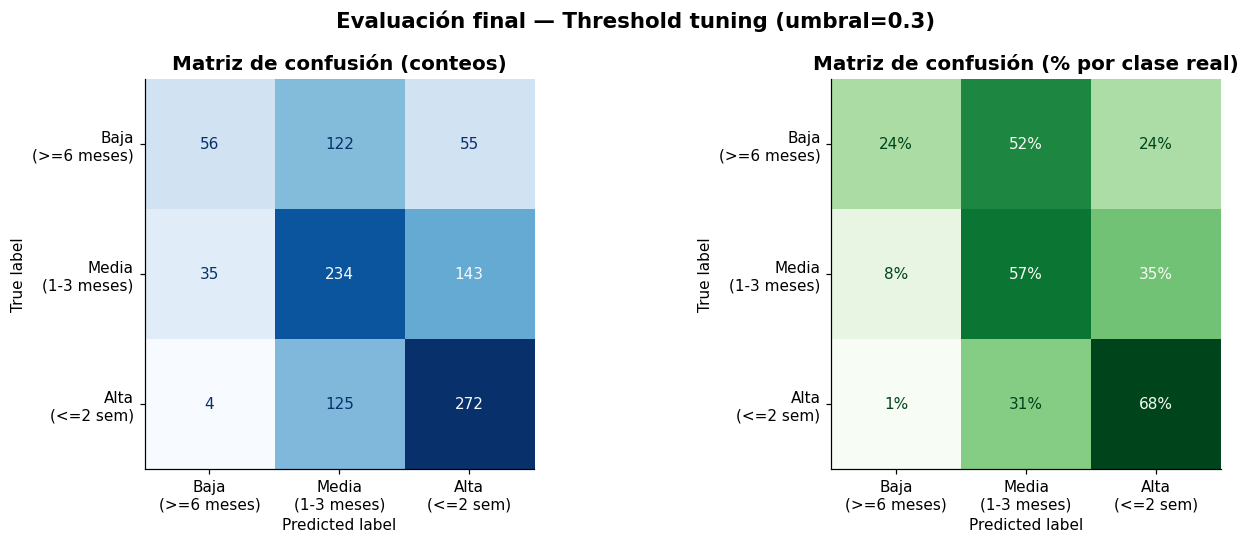

In [ ]:
nombres_clases = ['Baja\n(>=6 meses)', 'Media\n(1-3 meses)', 'Alta\n(<=2 sem)']
cm = confusion_matrix(y_test, y_pred_test)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=nombres_clases)
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matriz de confusión (conteos)')

cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_pct, display_labels=nombres_clases)
disp2.plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title('Matriz de confusión (% por clase real)')
for text in axes[1].texts:
    text.set_text(f"{float(text.get_text()):.0%}")

plt.suptitle(f'Evaluación final — {mejor_nombre}', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../../docs/viz_06_confusion_matrix.png', dpi=120, bbox_inches='tight')
plt.show()


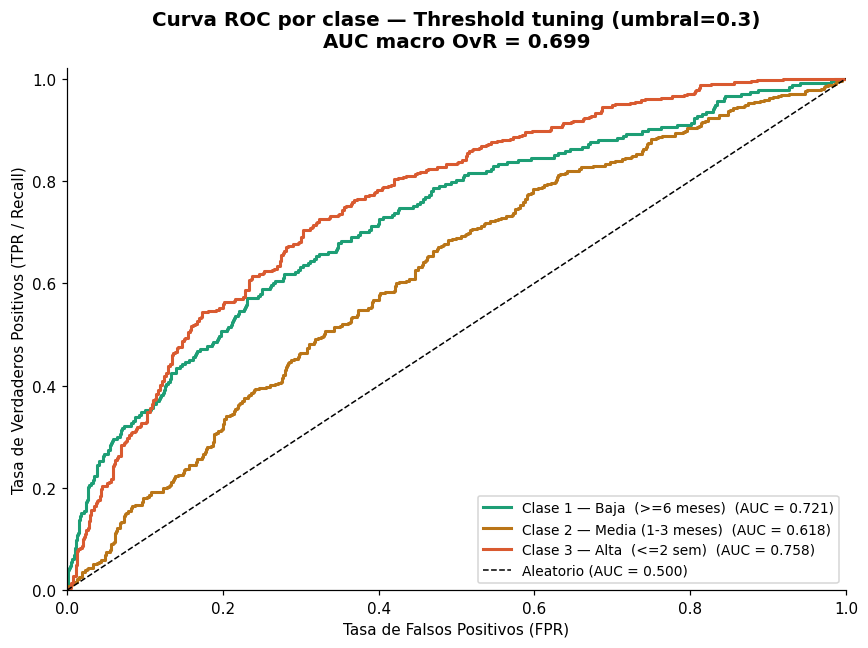

In [ ]:
from sklearn.preprocessing import label_binarize

clases      = [1, 2, 3]
nombres_roc = {1: 'Baja  (>=6 meses)', 2: 'Media (1-3 meses)', 3: 'Alta  (<=2 sem)'}
colores_roc = {1: TEAL, 2: AMBER, 3: CORAL}

y_test_bin = label_binarize(y_test, classes=clases)

fig, ax = plt.subplots(figsize=(8, 6))
for i, clase in enumerate(clases):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_proba_test[:, i])
    auc_clase   = roc_auc_score(y_test_bin[:, i], y_proba_test[:, i])
    ax.plot(fpr, tpr, color=colores_roc[clase], linewidth=2,
            label=f'Clase {clase} — {nombres_roc[clase]}  (AUC = {auc_clase:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Aleatorio (AUC = 0.500)')
ax.set_xlabel('Tasa de Falsos Positivos (FPR)')
ax.set_ylabel('Tasa de Verdaderos Positivos (TPR / Recall)')
ax.set_title(f'Curva ROC por clase — {mejor_nombre}\nAUC macro OvR = {auc_test:.3f}', pad=14)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlim([0, 1]); ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.savefig('../../docs/viz_08_roc_curve.png', dpi=120, bbox_inches='tight')
plt.show()


---
### Análisis de resultados por clase

> Los valores de F1 / Recall por clase se actualizan al ejecutar la celda de evaluación final.
> La clase *Baja* históricamente tiene recall bajo por ser la menos frecuente (~22% del dataset).
>
> **Estrategias de desbalance** probadas en la sección 3.8 (a continuación del modelado con nuevas variables).


---
## 5 — Importancia de features

Identificamos qué variables tienen más peso en las predicciones del modelo.

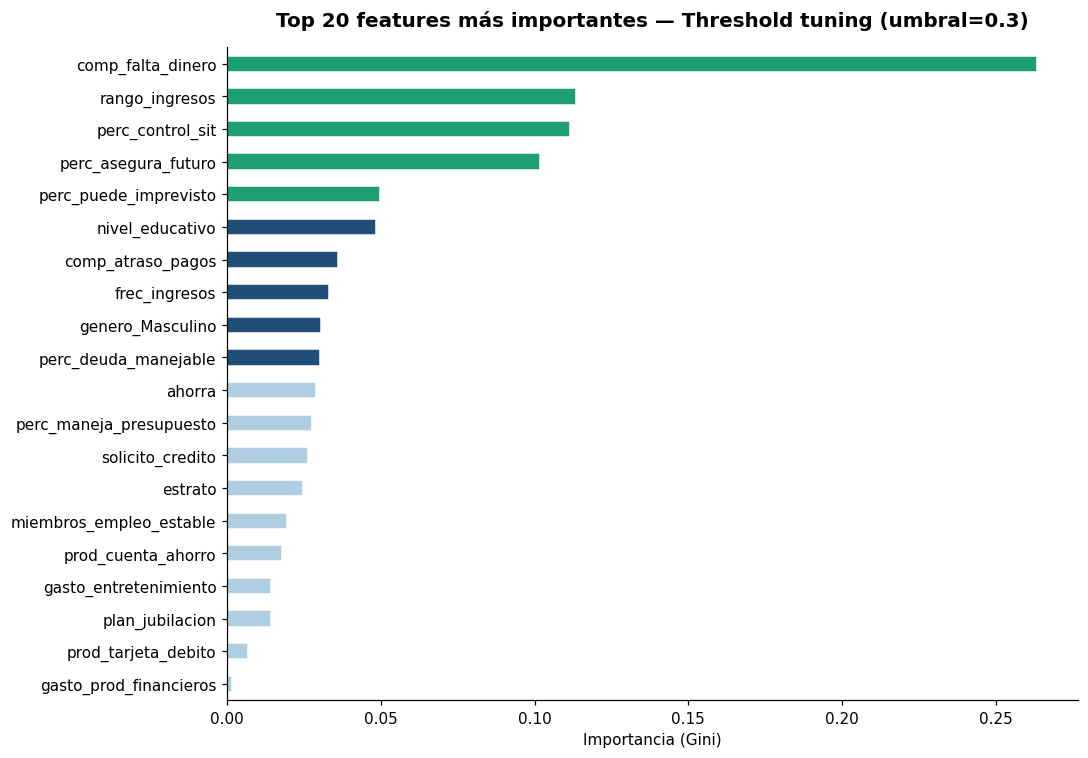

Top 10 features:
comp_falta_dinero        0.263617
rango_ingresos           0.113635
perc_control_sit         0.111567
perc_asegura_futuro      0.101704
perc_puede_imprevisto    0.049635
nivel_educativo          0.048486
comp_atraso_pagos        0.036053
frec_ingresos            0.033040
genero_Masculino         0.030646
perc_deuda_manejable     0.030168


In [ ]:
clf = mejor_pipe.named_steps['clf']

if hasattr(clf, 'feature_importances_'):
    importancias = pd.Series(clf.feature_importances_, index=X_train.columns)
    top20 = importancias.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    colores_imp = [TEAL if i < 5 else AZUL if i < 10 else '#AECDE1'
                  for i in range(len(top20))]
    top20.sort_values().plot(kind='barh', ax=ax, color=colores_imp[::-1],
                              edgecolor='white')
    ax.set_title(f'Top 20 features más importantes — {mejor_nombre}', pad=14)
    ax.set_xlabel('Importancia (Gini)')
    plt.tight_layout()
    plt.savefig('../../docs/viz_07_feature_importance.png', dpi=120, bbox_inches='tight')
    plt.show()

elif hasattr(clf, 'coef_'):
    # Logistic Regression: coeficientes promedio entre clases
    importancias = pd.Series(np.abs(clf.coef_).mean(axis=0), index=X_train.columns)
    top20 = importancias.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(10, 7))
    top20.sort_values().plot(kind='barh', ax=ax, color=AZUL, alpha=0.8, edgecolor='white')
    ax.set_title(f'Top 20 features — coeficientes absolutos promedio ({mejor_nombre})', pad=14)
    ax.set_xlabel('|Coeficiente| promedio')
    plt.tight_layout()
    plt.savefig('../../docs/viz_07_feature_importance.png', dpi=120, bbox_inches='tight')
    plt.show()

print('Top 10 features:')
print(importancias.sort_values(ascending=False).head(10).to_string())